# AI Programming Foundations Project
## by <i>Andreas Grotz</i>

## Table of Contents
- [Introduction](#intro)
- [Imports](#import)
- [Data Cleaning](#cleaning)
- [Exploratory Analysis](#analysis)
- [Visualization](#visual)
- [Summary](#summary)

<a id='intro'></a>
### Introduction

In this project, we build a pipeline for cleaning and exploring a dataset on Airbnb listings in NYC (https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data). Among others, the dataset contains information on neighbourhood, room type, reviews, and price, and we are going to explore the relations between these types of information. More precisely, we are interested in if and how the price depends on the neighbourhood, room type, and number of reviews per month.


<a id='import'></a>
### Imports

In this section, we import required Python modules, and we load our dataset to a Pandas dataframe.

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("AB_NYC_2019.csv")
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<a id='cleaning'></a>
### Data Cleaning

xxx

In [4]:
sum(df.duplicated())

0

In [5]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [6]:
df[df.last_review.isna()].number_of_reviews.sum()

np.int64(0)

In [7]:
def clean_review_columns(df):
    """
    A function that cleans missing values in the review columns.
    Cleaning is performed inplace.
    The date in last_review is set to a dummy value 9999-12-31.
    The number in reviews_per_month is set to 0.0.
    
    Args:
        df (dataframe): The Pandas dataframe
        
    Returns:
        None
    """
    df.loc[df.last_review.isna(), 'reviews_per_month']
    df.loc[df.last_review.isna(), 'reviews_per_month'] = 0.0
    df.loc[df.last_review.isna(), 'last_review'] = '9999-12-31'
    df['last_review'] = pd.to_datetime(df['last_review'])

In [8]:
clean_review_columns(df)

xxx

In [9]:
df[['price','reviews_per_month']].describe()

,price,reviews_per_month
count,48895.000000,48895.000000
mean,152.720687,1.090910
std,240.154170,1.597283
min,0.000000,0.000000
25%,69.000000,0.040000
50%,106.000000,0.370000
75%,175.000000,1.580000
max,10000.000000,58.500000


In [11]:
price005 = np.quantile(df.price, q=0.005)
print(f'price 0.5% quantile: {price005}')
price995 = np.quantile(df.price, q=0.995)
print(f'price 99.5% quantile: {price995}')
reviews005 = np.quantile(df.reviews_per_month, q=0.005)
print(f'reviews_per_month 0.5% quantile: {reviews005}')
reviews995 = np.quantile(df.reviews_per_month, q=0.995)
print(f'reviews_per_month 99.5% quantile: {reviews995}')

price 0.5% quantile: 26.0
price 99.5% quantile: 1000.0
reviews_per_month 0.5% quantile: 0.0
reviews_per_month 99.5% quantile: 7.97


In [12]:
def clean_outliers(df, col, qLower, qUpper):
    """
    A function that removes outliers in a given columns, as specified by lower and upper cutoff values.
    Cleaning is performed inplace.
    
    Args:
        df (dataframe): The Pandas dataframe
        col (str): The column name
        qLower float): The lower cutoff value
        qUpper float): The upper cutoff value
        
    Returns:
        None
    """
    indices_to_drop = df[(df[col] < qLower) | (df[col] > qUpper)].index
    df.drop(indices_to_drop, inplace=True)


In [13]:
clean_outliers(df, 'price', price005, price995)

In [14]:
clean_outliers(df, 'reviews_per_month', reviews005, reviews995)

xxx

In [15]:
def drop_na_values(df):
    """
    A function that removes any rows with NA values.
    Cleaning is performed inplace.
    
    Args:
        df (dataframe): The Pandas dataframe
        
    Returns:
        None
    """
    df.dropna(axis=0, inplace=True)

In [16]:
drop_na_values(df)

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 48148 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              48148 non-null  int64         
 1   name                            48148 non-null  str           
 2   host_id                         48148 non-null  int64         
 3   host_name                       48148 non-null  str           
 4   neighbourhood_group             48148 non-null  str           
 5   neighbourhood                   48148 non-null  str           
 6   latitude                        48148 non-null  float64       
 7   longitude                       48148 non-null  float64       
 8   room_type                       48148 non-null  str           
 9   price                           48148 non-null  int64         
 10  minimum_nights                  48148 non-null  int64         
 11  number_of_reviews 

<a id='analysis'></a>
### Exploratory Analysis

xxx

In [18]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.814800e+04,4.814800e+04,48148.000000,48148.000000,48148.000000,48148.000000,48148.000000,48148,48148.000000,48148.000000,48148.000000
mean,1.895959e+07,6.705218e+07,40.729073,-73.952440,142.088685,6.984901,22.902052,3651-03-16 11:45:31.477936,1.048963,7.206281,112.202355
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,26.000000,1.000000,0.000000,2011-03-28 00:00:00,0.000000,1.000000,0.000000
25%,9.430939e+06,7.728754e+06,40.690247,-73.983052,70.000000,1.000000,1.000000,2018-11-01 00:00:00,0.040000,1.000000,0.000000
50%,1.959066e+07,3.038336e+07,40.723100,-73.955730,107.000000,3.000000,5.000000,2019-06-13 00:00:00,0.370000,1.000000,44.000000
75%,2.907553e+07,1.069509e+08,40.763132,-73.936637,175.000000,5.000000,23.000000,2019-07-03 00:00:00,1.560000,2.000000,225.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,1000.000000,1250.000000,607.000000,9999-12-31 00:00:00,7.970000,327.000000,365.000000
std,1.097946e+07,7.828374e+07,0.054431,0.045648,116.865129,19.801229,43.245941,NaN,1.439269,33.189625,131.415369


In [41]:
def get_correlation(df, col1, col2):
    """
    A function that calculates the correlation between two columns in a dataframe.
    Cleaning is performed inplace.
    
    Args:
        df (dataframe): The Pandas dataframe
        col1 (str): Name of the first column
        col2 (str): Name of the second column
        
    Returns:
        float: The correlation between the two columns
    """
    corr_mat = df[[col1, col2]].corr()
    return corr_mat.loc[col1, col2]

In [42]:
corr = get_correlation(df, 'reviews_per_month', 'price')
print(corr)

-0.04999983804675285


In [47]:
def get_grouped_stats(df, stat_col, by_col):
    """
    A function that calculates descriptive statistics for a column in a dataframe, grouped by another column
    Cleaning is performed inplace.
    
    Args:
        df (dataframe): The Pandas dataframe
        stat_col (str): Name of the column, for which stats are calculated
        by_col (str): Name of the column, by which data are grouped
        
    Returns:
        float: The correlation between the two columns
    """
    return df.groupby(by=by_col)[stat_col].describe()

In [48]:
get_grouped_stats(df, 'price', 'neighbourhood_group')

,count,mean,std,min,25%,50%,75%,max
neighbourhood_group,,,,,,,,
Bronx,1060.0,86.574528,78.251411,26.0,47.0,66.0,99.25,1000.0
Brooklyn,19848.0,118.553255,94.508310,26.0,60.0,91.0,150.00,1000.0
Manhattan,21385.0,179.180734,133.939968,26.0,95.0,150.0,220.00,1000.0
Queens,5493.0,96.206445,75.031928,26.0,50.0,75.0,112.00,1000.0
Staten Island,362.0,100.082873,96.762289,27.0,50.0,75.0,110.00,1000.0


In [49]:
get_grouped_stats(df, 'price', 'room_type')

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,25085.0,194.954993,126.146948,28.0,120.0,160.0,225.0,1000.0
Private room,22022.0,85.157661,68.901868,26.0,50.0,70.0,95.0,1000.0
Shared room,1041.0,72.524496,83.986810,26.0,35.0,50.0,75.0,1000.0


<a id='visual'></a>
### Visualization

xxx

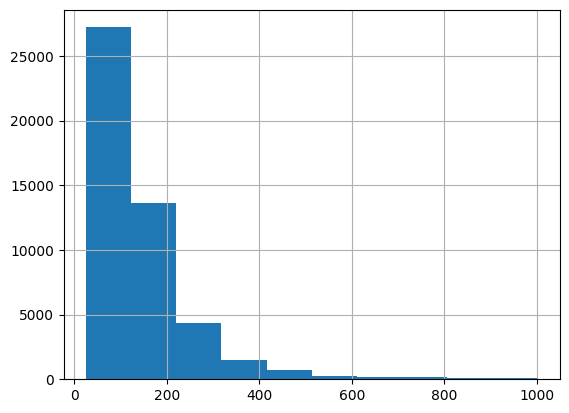

In [32]:
df.price.hist();

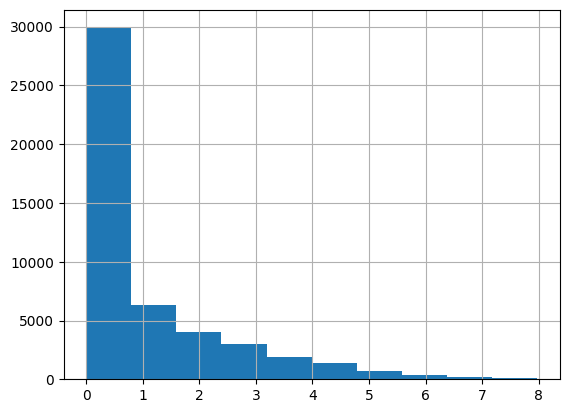

In [31]:
df.reviews_per_month.hist();

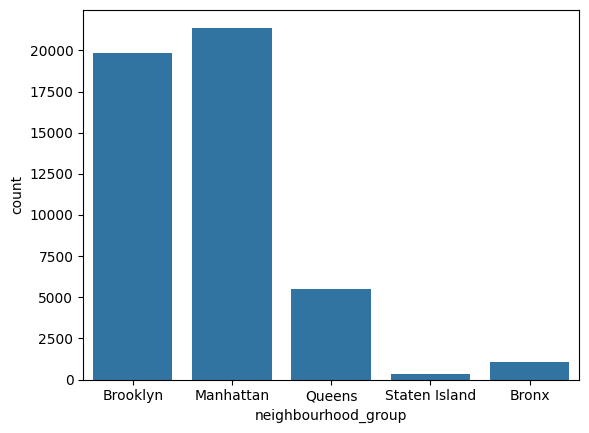

In [23]:
sns.countplot(data=df, x='neighbourhood_group');

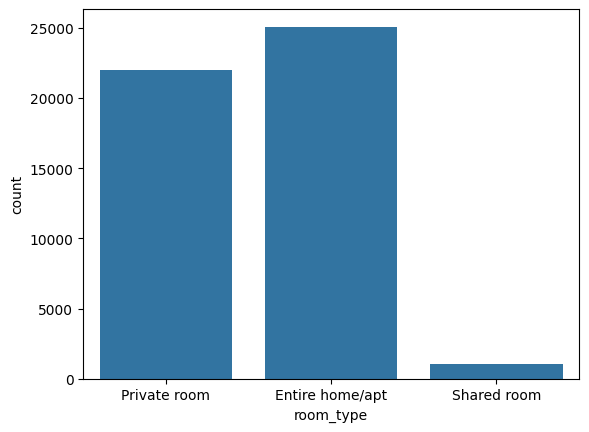

In [29]:
sns.countplot(data=df, x='room_type');

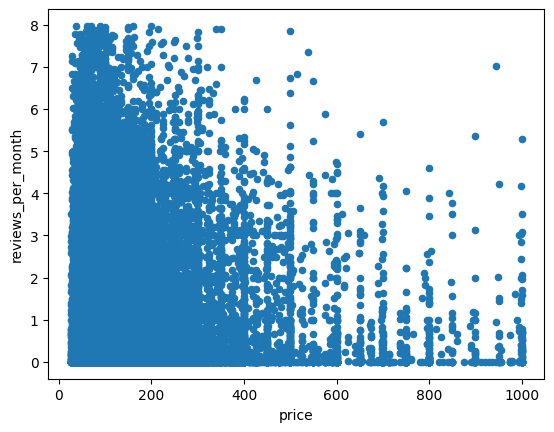

In [24]:
df.plot.scatter(x='price',y='reviews_per_month');

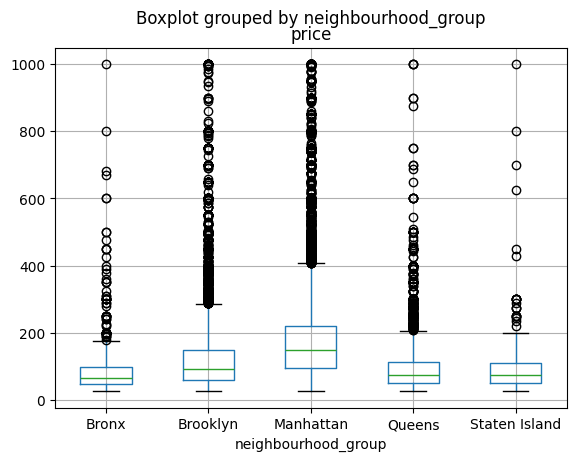

In [25]:
df.boxplot(column='price', by='neighbourhood_group');

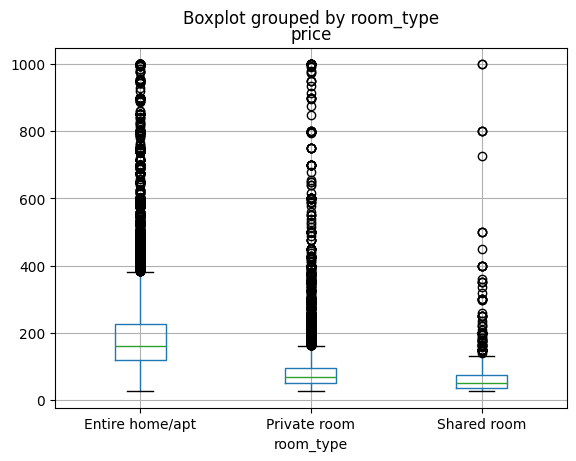

In [33]:
df.boxplot(column='price', by='room_type');

<a id='summary'></a>
### Summary

xxx

In [27]:
#pip freeze > requirements.txt